## Optimization Comparison
pandas, multiprocessing, dask


CPUs available: 2
Loaded 9,404 rows × 8 columns
product_name        object
brand               object
category           float64
variant_details     object
price              float64
sku                 object
available             bool
updated_at          object
dtype: object
Benchmark dataset: 498,412 rows (original × 53)

[Baseline]  Time=0.26s | CPU=55.8% | Mem=63.8MB | Throughput=1,930,263 rec/s


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


[Multiproc] Time=0.65s | CPU=83.5% | Mem=10.2MB | Throughput=770,899 rec/s
[Dask]      Time=1.37s | CPU=54.0% | Mem=128.9MB | Throughput=363,849 rec/s

=== Performance Summary ===
               Method   Time_s  CPU_pct  Memory_MB   Throughput
Baseline (Sequential) 0.258209     55.8  63.795200 1.930263e+06
      Multiprocessing 0.646533     83.5  10.244096 7.708990e+05
                 Dask 1.369833     54.0 128.905216 3.638488e+05


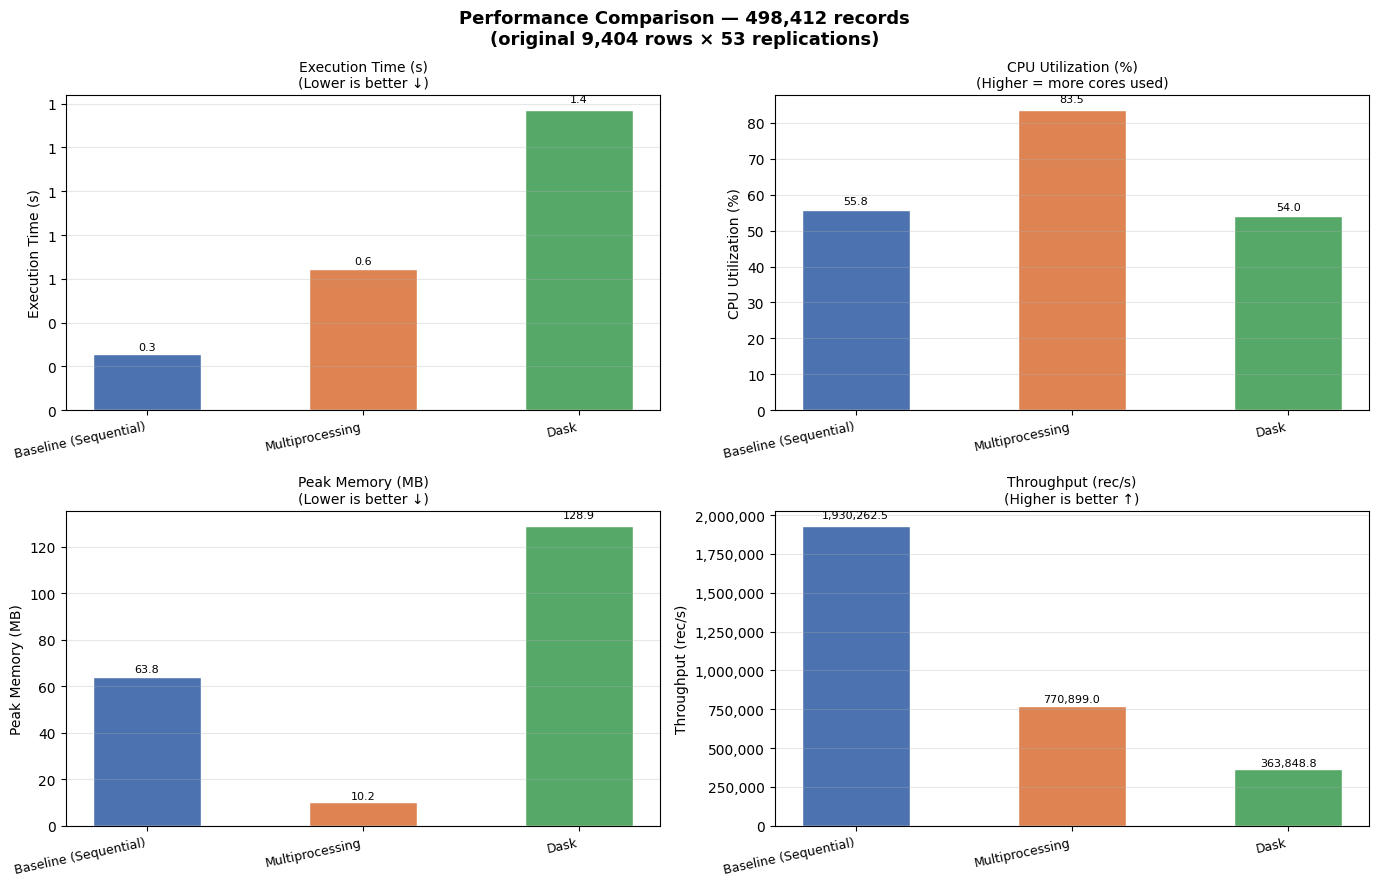

Chart saved → performance_comparison.png

=== Speedup vs Baseline ===
  Multiprocessing           → 0.40x faster | -60.1% throughput
  Dask                      → 0.19x faster | -81.2% throughput


In [3]:
# ============================================================
# Cell 1 — Install & Import
# ============================================================
!pip install pandas numpy psutil matplotlib dask[dataframe] -q

import pandas as pd
import numpy as np
import time, os, psutil, multiprocessing
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from concurrent.futures import ProcessPoolExecutor
import dask.dataframe as dd

CPU_COUNT = multiprocessing.cpu_count()
print(f"CPUs available: {CPU_COUNT}")

# ============================================================
# Cell 2 — Load Cleaned Data
# ============================================================
CLEANED_PATH = "/content/cleaned_data.csv"
df = pd.read_csv(CLEANED_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
print(df.dtypes)

# ── Scale up for meaningful benchmarks ──────────────────────
# 9k rows processes in milliseconds — replicate to ~500k rows
# so timing differences between methods are clearly visible
REPEAT = max(1, 500_000 // len(df))
df_bench = pd.concat([df] * REPEAT, ignore_index=True)
print(f"Benchmark dataset: {len(df_bench):,} rows (original × {REPEAT})")

# ============================================================
# Cell 3 — Helper: Measure Resource Usage
# ============================================================
def measure(fn, *args, **kwargs):
    proc = psutil.Process(os.getpid())
    mem_before = proc.memory_info().rss / 1e6
    psutil.cpu_percent(interval=None)          # warm up
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    elapsed = time.perf_counter() - t0
    cpu = psutil.cpu_percent(interval=None)
    peak_mem = proc.memory_info().rss / 1e6 - mem_before
    return result, elapsed, peak_mem, cpu

def throughput(n, elapsed):
    return n / elapsed if elapsed > 0 else float("inf")

# ============================================================
# Cell 4 — Processing Task
# ============================================================
def process_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    out = chunk.copy()

    # 1. Normalize price to 0–1
    if "price" in out.columns:
        mn, mx = out["price"].min(), out["price"].max()
        out["price_norm"] = (out["price"] - mn) / (mx - mn + 1e-9)

    # 2. Budget flag — price in bottom 25th percentile
    if "price" in out.columns:
        q25 = out["price"].quantile(0.25)
        out["is_budget"] = (out["price"] <= q25).astype(int)

    # 3. Encode category as integer code
    if "category" in out.columns:
        out["category_code"] = out["category"].astype("category").cat.codes

    # 4. Encode brand as integer code
    if "brand" in out.columns:
        out["brand_code"] = out["brand"].astype("category").cat.codes

    # 5. Availability as int (True→1, False→0)
    if "available" in out.columns:
        out["available_int"] = out["available"].astype(int)

    # 6. Parse updated_at → year, month features
    if "updated_at" in out.columns:
        dt = pd.to_datetime(out["updated_at"], errors="coerce")
        out["updated_year"]  = dt.dt.year
        out["updated_month"] = dt.dt.month

    # 7. Title length as a simple text feature
    if "product_name" in out.columns:
        out["name_length"] = out["product_name"].str.len()

    return out

# ============================================================
# Cell 5 — BASELINE (Sequential, Single-Threaded)
# ============================================================
def baseline_pipeline(data):
    return process_chunk(data)

result_base, t_base, mem_base, cpu_base = measure(baseline_pipeline, df_bench)
tp_base = throughput(len(df_bench), t_base)

print(f"\n[Baseline]  Time={t_base:.2f}s | CPU={cpu_base:.1f}% | "
      f"Mem={mem_base:.1f}MB | Throughput={tp_base:,.0f} rec/s")

# ============================================================
# Cell 6 — OPTIMIZATION 1: Multiprocessing (ProcessPoolExecutor)
# ============================================================
# NOTE: Multiprocessing is better than threading for CPU-bound tasks
# because it bypasses Python's GIL and uses all available cores.
N_WORKERS = CPU_COUNT   # 2 cores on Colab

def mp_pipeline(data, n_workers=N_WORKERS):
    chunks = np.array_split(data, n_workers)
    with ProcessPoolExecutor(max_workers=n_workers) as ex:
        parts = list(ex.map(process_chunk, chunks))
    return pd.concat(parts, ignore_index=True)

result_mp, t_mp, mem_mp, cpu_mp = measure(mp_pipeline, df_bench)
tp_mp = throughput(len(df_bench), t_mp)

print(f"[Multiproc] Time={t_mp:.2f}s | CPU={cpu_mp:.1f}% | "
      f"Mem={mem_mp:.1f}MB | Throughput={tp_mp:,.0f} rec/s")

# ============================================================
# Cell 7 — OPTIMIZATION 2: Dask (Distributed DataFrame)
# ============================================================
def dask_pipeline(data):
    ddf = dd.from_pandas(data, npartitions=CPU_COUNT)

    if "price" in ddf.columns:
        mn = ddf["price"].min().compute()
        mx = ddf["price"].max().compute()
        ddf["price_norm"] = (ddf["price"] - mn) / (mx - mn + 1e-9)
        q25 = ddf["price"].quantile(0.25).compute()
        ddf["is_budget"] = (ddf["price"] <= q25).astype(int)

    # Fix: categorize() first so cat.codes works with unknown categories
    if "category" in ddf.columns:
        ddf = ddf.categorize(columns=["category"])
        ddf["category_code"] = ddf["category"].cat.codes

    if "brand" in ddf.columns:
        ddf = ddf.categorize(columns=["brand"])
        ddf["brand_code"] = ddf["brand"].cat.codes

    if "available" in ddf.columns:
        ddf["available_int"] = ddf["available"].astype(int)

    if "product_name" in ddf.columns:
        ddf["name_length"] = ddf["product_name"].str.len()

    return ddf.compute()

result_dsk, t_dsk, mem_dsk, cpu_dsk = measure(dask_pipeline, df_bench)
tp_dsk = throughput(len(df_bench), t_dsk)

print(f"[Dask]      Time={t_dsk:.2f}s | CPU={cpu_dsk:.1f}% | "
      f"Mem={mem_dsk:.1f}MB | Throughput={tp_dsk:,.0f} rec/s")

# ============================================================
# Cell 8 — Save Performance Metrics
# ============================================================
metrics = pd.DataFrame({
    "Method"     : ["Baseline (Sequential)", "Multiprocessing", "Dask"],
    "Time_s"     : [t_base, t_mp, t_dsk],
    "CPU_pct"    : [cpu_base, cpu_mp, cpu_dsk],
    "Memory_MB"  : [mem_base, mem_mp, mem_dsk],
    "Throughput" : [tp_base, tp_mp, tp_dsk],
})

pd.DataFrame([metrics.iloc[0]]).to_csv("performance_before.csv", index=False)
pd.DataFrame(metrics.iloc[1:]).to_csv("performance_after.csv",  index=False)

print("\n=== Performance Summary ===")
print(metrics.to_string(index=False))

# ============================================================
# Cell 9 — Visualize Results
# ============================================================
labels = metrics["Method"]
x      = np.arange(len(labels))
colors = ["#4c72b0", "#dd8452", "#55a868"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    f"Performance Comparison — {len(df_bench):,} records\n"
    f"(original {len(df):,} rows × {REPEAT} replications)",
    fontsize=13, fontweight="bold"
)

plots = [
    ("Time_s",      "Execution Time (s)",    "Lower is better ↓"),
    ("CPU_pct",     "CPU Utilization (%)",   "Higher = more cores used"),
    ("Memory_MB",   "Peak Memory (MB)",      "Lower is better ↓"),
    ("Throughput",  "Throughput (rec/s)",    "Higher is better ↑"),
]

for ax, (col, ylabel, note) in zip(axes.flat, plots):
    bars = ax.bar(x, metrics[col], color=colors, edgecolor="white", width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=12, ha="right", fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel}\n({note})", fontsize=10)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.02,
                f"{h:,.1f}", ha="center", va="bottom", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=150)
plt.show()
print("Chart saved → performance_comparison.png")

# ============================================================
# Cell 10 — Speedup Summary
# ============================================================
print("\n=== Speedup vs Baseline ===")
for _, row in metrics.iloc[1:].iterrows():
    speedup = t_base / row["Time_s"] if row["Time_s"] > 0 else float("inf")
    tp_gain = ((row["Throughput"] - tp_base) / tp_base) * 100
    print(f"  {row['Method']:<25} → {speedup:.2f}x faster | {tp_gain:+.1f}% throughput")